In [2]:
import eurostat
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.tsa.vector_ar.vecm import coint_johansen, VECM
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import pmdarima as pm

from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn

In [3]:
import eurostat
import pandas as pd
import os

def fetch_and_clean_eurostat(dataset_code, filter_params, col_name):
    df_raw = eurostat.get_data_df(dataset_code, filter_pars=filter_params)
    time_col = [col for col in df_raw.columns if 'TIME_PERIOD' in col][0]
    id_vars = df_raw.columns[:df_raw.columns.get_loc(time_col)+1].tolist()
    df_melted = df_raw.melt(id_vars=id_vars, var_name='date', value_name=col_name)
    df_melted['date'] = pd.to_datetime(df_melted['date'].str.replace('-M', '-'), format='%Y-%m')
    df_clean = df_melted[['date', col_name]].copy()
    df_clean[col_name] = pd.to_numeric(df_clean[col_name], errors='coerce')
    df_clean = df_clean[df_clean['date'] >= '2010-01-01']
    df_clean = df_clean.dropna()
    df_clean = df_clean.drop_duplicates(subset=['date'])
    return df_clean

# 1. Consumul de Energie
params_consum = {'geo': ['RO'], 'nrg_bal': ['AIM'], 'siec': ['E7000'], 'unit': ['GWH']}
df_consum = fetch_and_clean_eurostat('nrg_cb_em', params_consum, 'Consum_Energie_GWh')

# 2. Productia Industriala
params_industrie = {'geo': ['RO'], 'nace_r2': ['B-D'], 's_adj': ['NSA'], 'unit': ['I21']}
df_industrie = fetch_and_clean_eurostat('sts_inpr_m', params_industrie, 'Productie_Industriala_Idx')

# 3. Inflatie Energie (Sudura istoricului pe baza I15)
params_inflatie_old = {'geo': ['RO'], 'coicop': ['CP0451'], 'unit': ['I15']}
df_inflatie_old = fetch_and_clean_eurostat('prc_hicp_midx', params_inflatie_old, 'Inflatie_Energie_Ipc')

params_inflatie_new = {'geo': ['RO'], 'coicop18': ['CP04510'], 'unit': ['I15']}
df_inflatie_new = fetch_and_clean_eurostat('prc_hicp_minr', params_inflatie_new, 'Inflatie_Energie_Ipc')

df_inflatie = pd.concat([df_inflatie_old, df_inflatie_new])
df_inflatie = df_inflatie.drop_duplicates(subset=['date'], keep='last')

# Unificare Finala
df = pd.merge(df_consum, df_industrie, on='date', how='inner')
df = pd.merge(df, df_inflatie, on='date', how='inner')
df.set_index('date', inplace=True)
df.sort_index(inplace=True)

# Salvare in folderul corect
output_path = os.path.join('..', 'data', 'baza_date_proiect.xlsx')
df.to_excel(output_path)

print("Shape final:", df.shape)
print("Interval date:", df.index.min().date(), "până la", df.index.max().date())
print("\nPrimele 5 înregistrări:")
df.head(5)

Shape final: (195, 3)
Interval date: 2010-01-01 până la 2026-03-01

Primele 5 înregistrări:


,Consum_Energie_GWh,Productie_Industriala_Idx,Inflatie_Energie_Ipc
date,,,
2010-01-01,4802.0,60.6,72.99
2010-02-01,4496.0,63.7,72.99
2010-03-01,4606.0,73.5,72.99
2010-04-01,4032.0,67.8,72.99
2010-05-01,3967.0,70.1,72.99


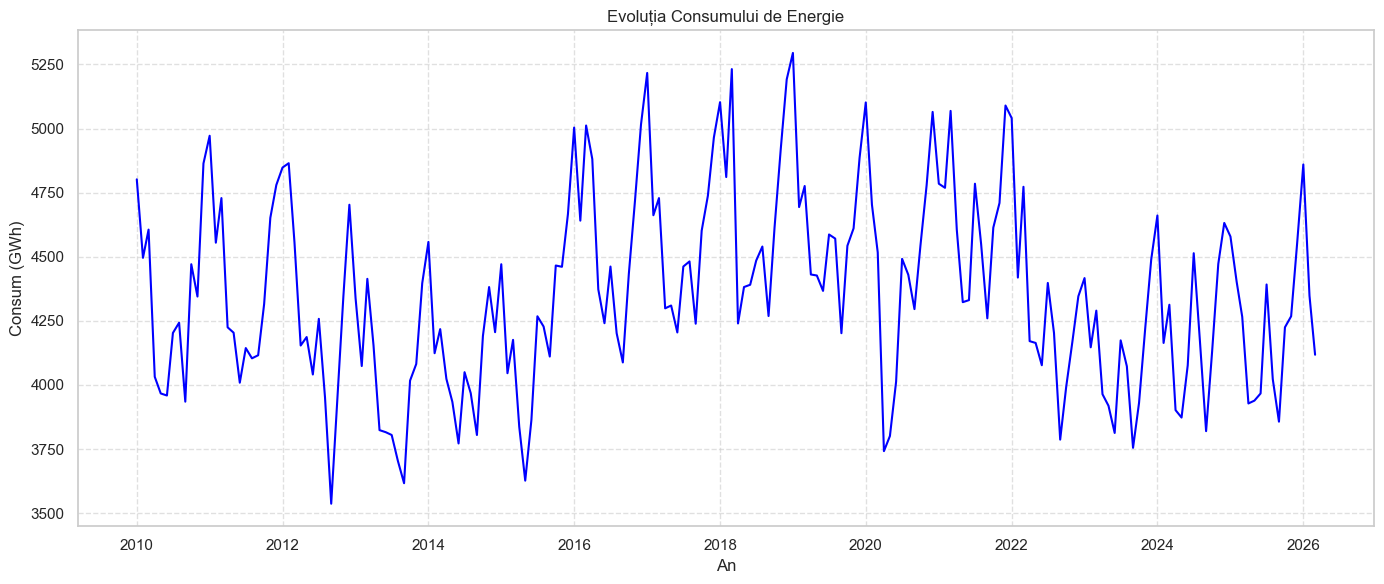

In [4]:
df.sort_index(inplace=True)

plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Consum_Energie_GWh'], color='blue', linewidth=1.5)

plt.title('Evoluția Consumului de Energie')
plt.xlabel('An')
plt.ylabel('Consum (GWh)')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [5]:
#Train-test split

train = df['Consum_Energie_GWh'][:-24]
test = df['Consum_Energie_GWh'][-24:]

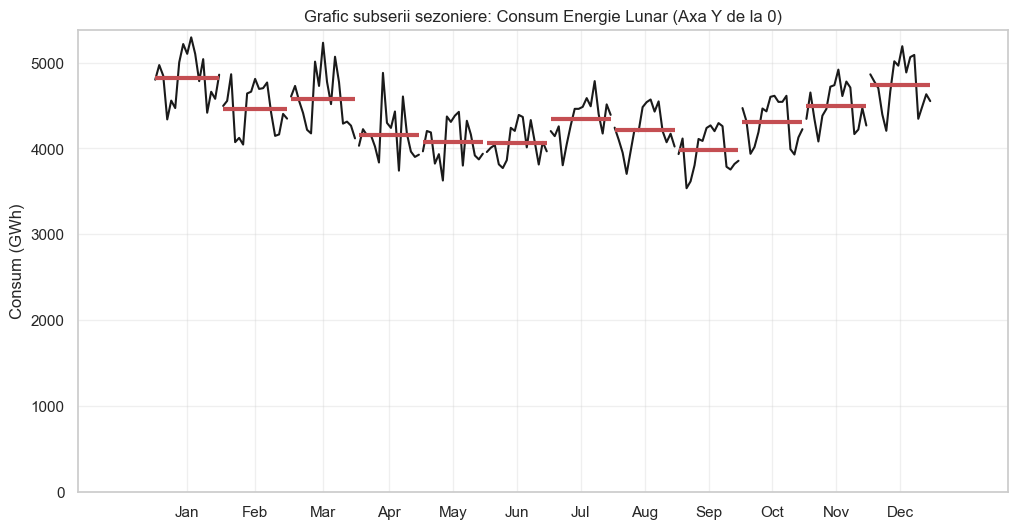

In [6]:
from statsmodels.graphics.tsaplots import month_plot
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))
month_plot(df['Consum_Energie_GWh'].dropna(), ax=ax)

# Aici e magia: forțăm axa Y să înceapă de la 0
ax.set_ylim(bottom=0)

plt.title('Grafic subserii sezoniere: Consum Energie Lunar (Axa Y de la 0)')
plt.ylabel('Consum (GWh)')
plt.grid(True, alpha=0.3)
plt.show()

In [7]:
import pmdarima as pm

# pmdarima rulează testul Canova-Hansen în spate și îți dă concluzia.
# Dacă rezultatul este 0 -> Sezonalitate stabilă (H0 acceptată)
# Dacă rezultatul este 1 -> Sezonalitate instabilă (H1 acceptată)

rezultat_ch = pm.arima.nsdiffs(df['Consum_Energie_GWh'].dropna(), m=12, test='ch')

print("--- Rezultat Test Canova-Hansen ---")
print(f"Valoarea returnată: {rezultat_ch}")

if rezultat_ch > 0:
    print("Concluzie: Tiparul sezonier este INSTABIL (respinge H0).")
else:
    print("Concluzie: Tiparul sezonier este STABIL (acceptă H0).")

--- Rezultat Test Canova-Hansen ---
Valoarea returnată: 0
Concluzie: Tiparul sezonier este STABIL (acceptă H0).


Rezultatele testului Canova-Hansen demonstreaza ca sezonalitatea prezenta in seria de consum energetic este una stabila. Deoarece ipoteza nula a fost acceptata, se poate concluziona ca tiparul sezonier nu necesita aplicarea unei diferentieri sezoniere pentru a asigura stationaritatea. Aceasta observatie sustine utilizarea seriei originale in procesul de modelare ulterioara, deoarece comportamentul sezonier al datelor se mentine constant si predictibil pe intreaga perioada analizata.

In [8]:
from statsmodels.tsa.stattools import adfuller, kpss
import warnings
warnings.filterwarnings("ignore")

def check_stationarity(series, name):
    print(f"--- Teste de Stationaritate pentru {name} ---")

    # ADF Test
    adf_res = adfuller(series)
    print(f"ADF p-value: {adf_res[1]:.4f}")

    # KPSS Test
    kpss_res = kpss(series, regression='c', nlags="auto")
    print(f"KPSS p-value: {kpss_res[1]:.4f}")

    # Logica de decizie
    # ADF - vrem p < 0.05 pentru a respinge H0 (stationara)
    # KPSS (H0: seria este stationara) - vrem p > 0.05 pentru a accepta H0 (stationara)
    
    if adf_res[1] < 0.05 and kpss_res[1] > 0.05:
        print("Concluzie: Seria este probabil STATIONARA.\n")
    else:
        print("Concluzie: Seria este probabil NESTATIONARA (necesita diferentiere).\n")

# Aici folosim coloana ta specifica
check_stationarity(df['Consum_Energie_GWh'], "Consum Energie")

--- Teste de Stationaritate pentru Consum Energie ---
ADF p-value: 0.2492
KPSS p-value: 0.1000
Concluzie: Seria este probabil NESTATIONARA (necesita diferentiere).



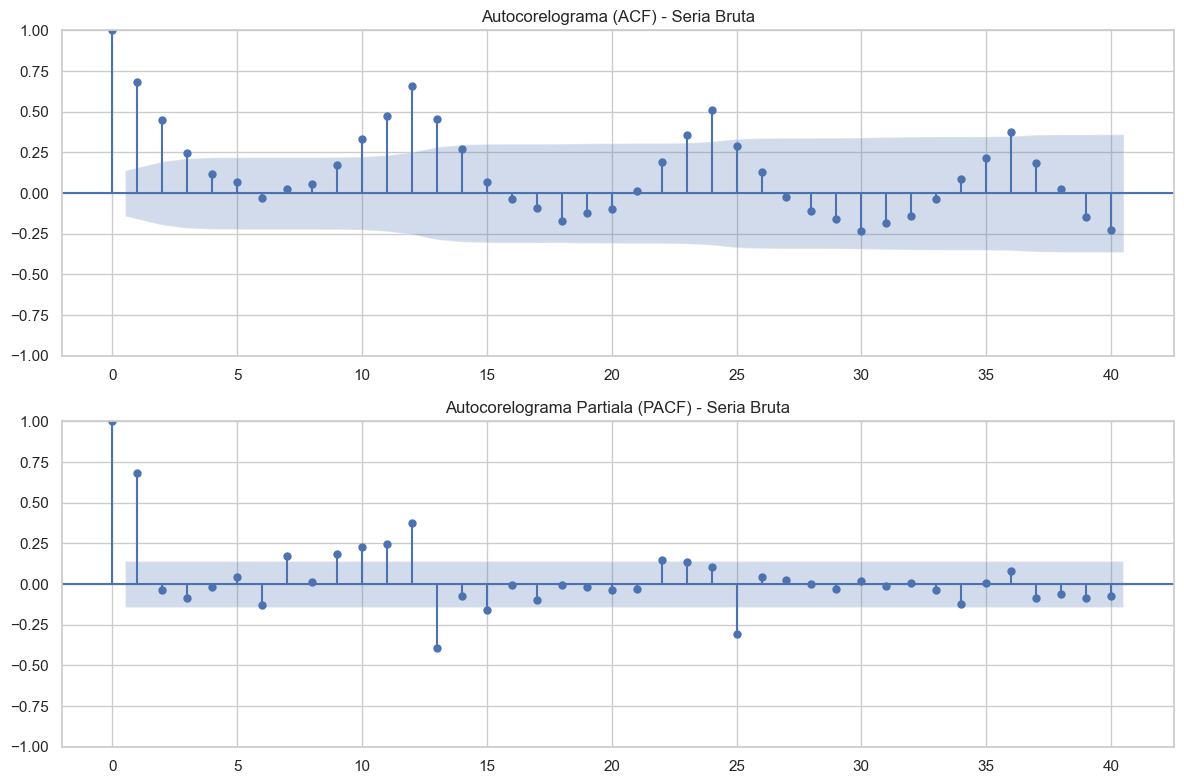

In [9]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# ACF
plot_acf(df['Consum_Energie_GWh'].dropna(), ax=axes[0], lags=40)
axes[0].set_title('Autocorelograma (ACF) - Seria Bruta')

# PACF
plot_pacf(df['Consum_Energie_GWh'].dropna(), ax=axes[1], lags=40, method='ywm')
axes[1].set_title('Autocorelograma Partiala (PACF) - Seria Bruta')

plt.tight_layout()
plt.show()

Corelograma ACF confirma prezenta unei sezonalitati anuale clare prin valorile semnificative la lag-urile 12, 24 si 36. Chiar daca testele de stabilitate sugereaza un tipar determinist, persistenta acestor corelatii justifica includerea parametrilor sezonieri in modelul SARIMA pentru a capta corect ciclicitatea consumului.

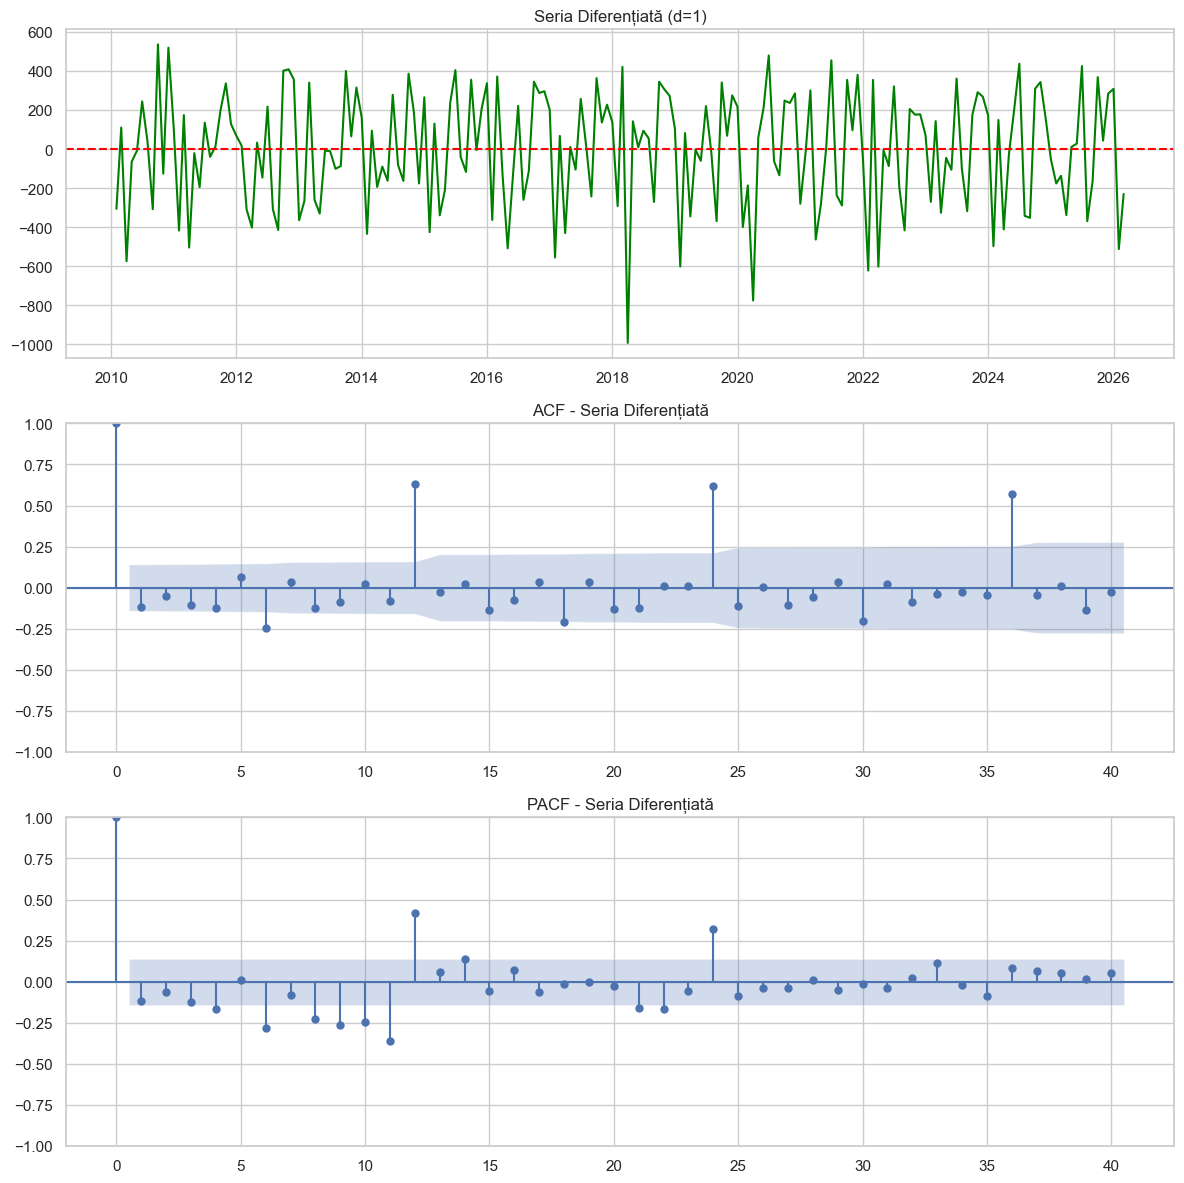

In [10]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# 1. Calculăm seria diferențiată (d=1)
# Eliminăm primul rând care devine NaN
df_diff = df['Consum_Energie_GWh'].diff().dropna()

# 2. Vizualizare: Seria diferențiată, ACF și PACF
fig, axes = plt.subplots(3, 1, figsize=(12, 12))

# Plot Seria Diferențiată
axes[0].plot(df_diff, color='green')
axes[0].set_title('Seria Diferențiată (d=1)')
axes[0].axhline(0, color='red', linestyle='--') # Linia mediană

# Plot ACF
plot_acf(df_diff, ax=axes[1], lags=40)
axes[1].set_title('ACF - Seria Diferențiată')

# Plot PACF
plot_pacf(df_diff, ax=axes[2], lags=40, method='ywm')
axes[2].set_title('PACF - Seria Diferențiată')

plt.tight_layout()
plt.show()

SAR: 2

SMA: 3

AR: max 1

MA: max 1

In [11]:
import pmdarima as pm

model_sarima = pm.auto_arima(train, 
                      d=1,                # Diferențiere simplă
                      D=0,                
                      m=12,               # Frecvență lunară
                      
                      # Limite nesezoniere (AR maxim 1, MA maxim 1)
                      start_p=0, max_p=1,
                      start_q=0, max_q=1,
                      
                      # Limite sezoniere (SAR maxim 2, SMA maxim 3)
                      start_P=0, max_P=2,
                      start_Q=0, max_Q=3,
                      
                      seasonal=True,
                      trace=True,         # Vedem cum caută
                      error_action='ignore',
                      suppress_warnings=True,
                      stepwise=True)

print(model_sarima.summary())

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=2414.596, Time=0.03 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=2321.140, Time=0.17 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=2365.264, Time=0.16 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=2412.613, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=2413.028, Time=0.02 sec
 ARIMA(1,1,0)(2,0,0)[12] intercept   : AIC=2289.411, Time=0.53 sec
 ARIMA(1,1,0)(2,0,1)[12] intercept   : AIC=inf, Time=1.36 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=inf, Time=0.50 sec
 ARIMA(0,1,0)(2,0,0)[12] intercept   : AIC=2294.397, Time=0.47 sec
 ARIMA(1,1,1)(2,0,0)[12] intercept   : AIC=inf, Time=0.66 sec
 ARIMA(0,1,1)(2,0,0)[12] intercept   : AIC=2284.764, Time=0.47 sec
 ARIMA(0,1,1)(1,0,0)[12] intercept   : AIC=2317.970, Time=0.18 sec
 ARIMA(0,1,1)(2,0,1)[12] intercept   : AIC=2257.598, Time=0.94 sec
 ARIMA(0,1,1)(1,0,1)[12] intercept   : AIC=inf, Time=0.61 sec
 ARIMA(0,1,1)(2,0,2)[12] intercept   : 

Modelul selectat este  SARIMA(0,1,1)(2,0,1)

Conform testului Ljung_Box nu am autocorelare in reziduuri.

Conform testului Jarque Bera teoretic nu am reziduuri normal distribuite, dar as putea spune ca am o distributia aproape normal distribuita, ea fiind usor leptokurtica.

Conform testului de heteroscedasticitate nu am reziduuri heteroscedastice, ele fiind homoscedastice, deci au varianta constanta.

--- Tabel Metrici Model ---
          Model Câștigător
MAE             226.271525
MAPE (%)          5.281349
MASE              0.946719
RMSE            256.894210
AIC            2257.598030
BIC            2276.412821


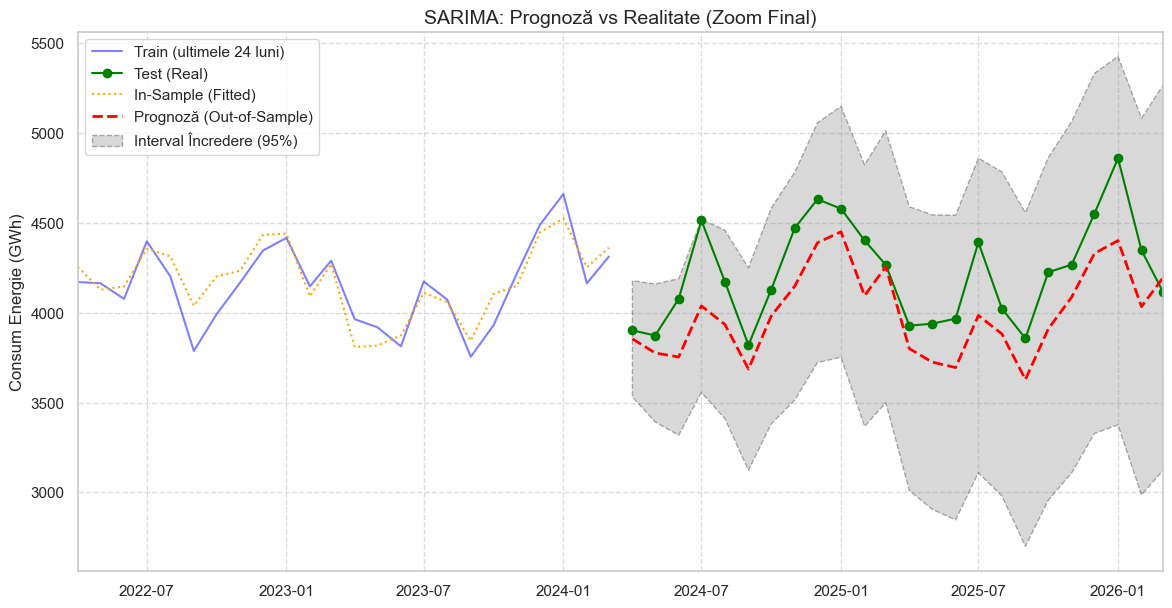

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Prognoză Out-of-sample (pe setul de test)
forecast_values, conf_int = model_sarima.predict(n_periods=len(test), return_conf_int=True)
forecast_series = pd.Series(forecast_values, index=test.index)
conf_int_df = pd.DataFrame(conf_int, index=test.index, columns=['lower', 'upper'])

# 2. Fitted values In-sample (pentru a vedea cum a învățat pe train)
in_sample_preds = model_sarima.predict_in_sample()
in_sample_series = pd.Series(in_sample_preds, index=train.index)

# 3. Calcul Metricilor
mae = mean_absolute_error(test, forecast_series)
rmse = np.sqrt(mean_squared_error(test, forecast_series))
mape = np.mean(np.abs((test - forecast_series) / test)) * 100

# MASE (Mean Absolute Scaled Error)
naive_mae_train = np.mean(np.abs(train.diff().dropna()))
mase = mae / naive_mae_train

metrics = {
    "MAE": mae,
    "MAPE (%)": mape,
    "MASE": mase,
    "RMSE": rmse,
    "AIC": model_sarima.aic(),
    "BIC": model_sarima.bic()
}

df_metrics = pd.DataFrame(metrics, index=["Model Câștigător"])
print("--- Tabel Metrici Model ---")
print(df_metrics.T)

# 4. Vizualizare cu Zoom și Stilizat
plt.figure(figsize=(14, 7))

# Plot train (doar ultimul segment de 24 luni pentru claritate)
# Ajustează indexul dacă train e prea scurt
zoom_start = train.index[-24] 
zoom_end = test.index[-1]

plt.plot(train.loc[zoom_start:].index, train.loc[zoom_start:], label='Train (ultimele 24 luni)', color='blue', alpha=0.5)
plt.plot(test.index, test, label='Test (Real)', color='green', marker='o', markersize=6)

# Plot in-sample (fitted) și out-of-sample (forecast)
plt.plot(in_sample_series.loc[zoom_start:].index, in_sample_series.loc[zoom_start:], label='In-Sample (Fitted)', color='orange', linestyle=':')
plt.plot(forecast_series.index, forecast_series, label='Prognoză (Out-of-Sample)', color='red', linestyle='--', linewidth=2)

# Plot interval de încredere stilizat (Gri cu margine)
plt.fill_between(conf_int_df.index, conf_int_df['lower'], conf_int_df['upper'], 
                 color='gray', alpha=0.3, label='Interval Încredere (95%)',
                 edgecolor='black', linestyle='--')

# Setări zoom și formatare
plt.xlim(zoom_start, zoom_end)
plt.title('SARIMA: Prognoză vs Realitate (Zoom Final)', fontsize=14)
plt.ylabel('Consum Energie (GWh)')
plt.legend(loc='upper left')
plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.show()

In [13]:
from statsmodels.stats.diagnostic import het_arch

# Aplicăm testul Engle (Lagrange Multiplier)
# Rezultatul confirmă (sau infirmă) dacă ai nevoie de GARCH
lm_stat, p_value, f_stat, f_p_value = het_arch(model_sarima.resid(), nlags=12)

print(f"Test Engle (LM Test pentru ARCH): p-value = {p_value:.4f}")

if p_value > 0.05:
    print("Concluzie pentru raport: Nu există efecte ARCH. Nu este necesar un model GARCH.")
else:
    print("Concluzie pentru raport: Există efecte ARCH! Aici ar trebui un model GARCH.")

Test Engle (LM Test pentru ARCH): p-value = 0.7388
Concluzie pentru raport: Nu există efecte ARCH. Nu este necesar un model GARCH.


--- Tabel Metrici Holt-Winters ---
          Holt-Winters (ETS)
MAE               197.035007
MAPE (%)            4.612506
MASE                0.824394
RMSE              229.501341
AIC              1747.261972
BIC              1797.528589


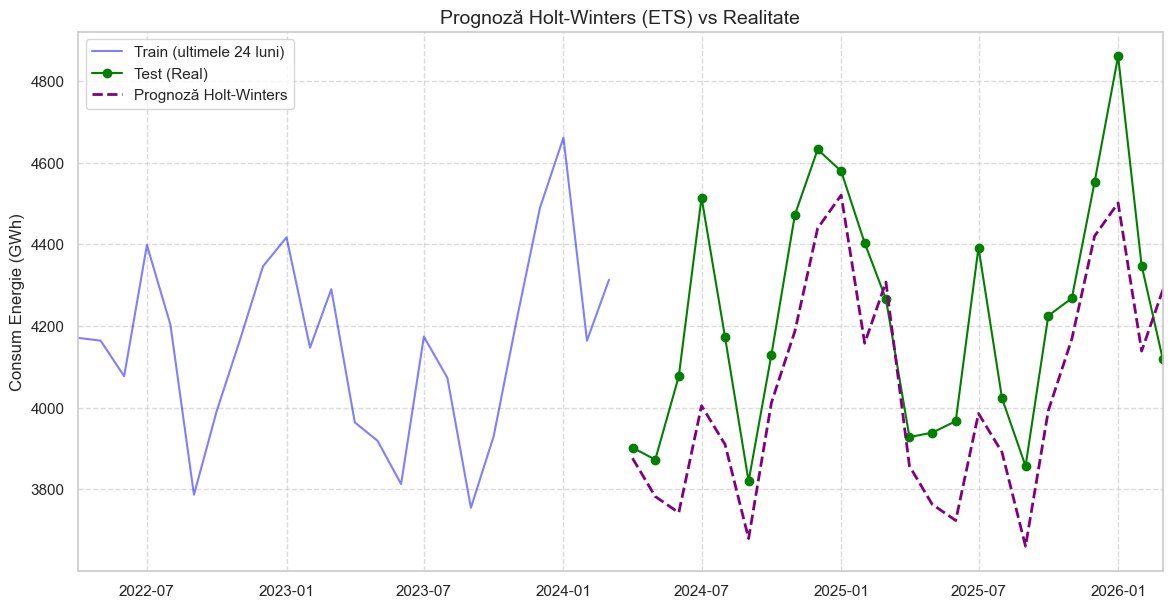

In [14]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Inițializare și Fit model Holt-Winters
hw_model = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=12).fit()

# 2. Prognoză pe setul de test
hw_forecast = hw_model.forecast(steps=len(test))
hw_forecast_series = pd.Series(hw_forecast, index=test.index)

# 3. Calcul Metricilor
mae_hw = mean_absolute_error(test, hw_forecast_series)
rmse_hw = np.sqrt(mean_squared_error(test, hw_forecast_series))
mape_hw = np.mean(np.abs((test - hw_forecast_series) / test)) * 100

# MASE
naive_mae_train = np.mean(np.abs(train.diff().dropna()))
mase_hw = mae_hw / naive_mae_train

# Adăugare AIC și BIC
metrics_hw = {
    "MAE": mae_hw,
    "MAPE (%)": mape_hw,
    "MASE": mase_hw,
    "RMSE": rmse_hw,
    "AIC": hw_model.aic,
    "BIC": hw_model.bic
}

df_metrics_hw = pd.DataFrame(metrics_hw, index=["Holt-Winters (ETS)"])
print("--- Tabel Metrici Holt-Winters ---")
print(df_metrics_hw.T)

# 4. Vizualizare (Zoom pe ultimele 24 luni + test)
zoom_start = train.index[-24] 
zoom_end = test.index[-1]

plt.figure(figsize=(14, 7))

plt.plot(train.loc[zoom_start:].index, train.loc[zoom_start:], label='Train (ultimele 24 luni)', color='blue', alpha=0.5)
plt.plot(test.index, test, label='Test (Real)', color='green', marker='o', markersize=6)
plt.plot(hw_forecast_series.index, hw_forecast_series, label='Prognoză Holt-Winters', color='purple', linestyle='--', linewidth=2)

# Setări grafic
plt.xlim(zoom_start, zoom_end)
plt.title('Prognoză Holt-Winters (ETS) vs Realitate', fontsize=14)
plt.ylabel('Consum Energie (GWh)')
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

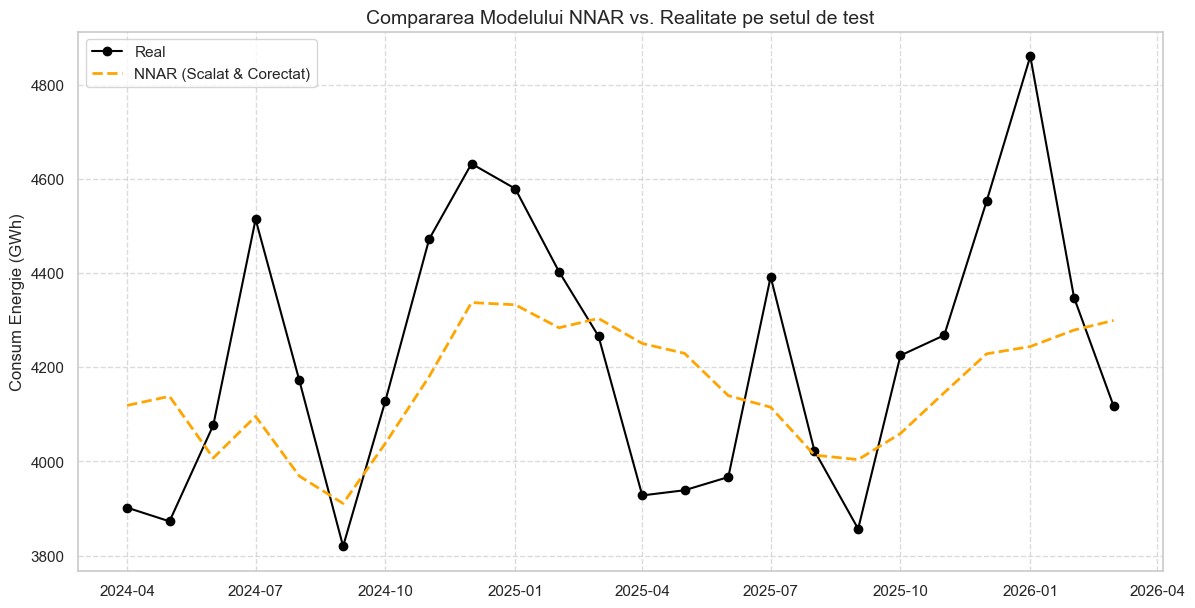

In [15]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ==========================================
# 0. INIȚIALIZARE ȘI SCALARE DATE
# ==========================================
# Inițializăm scaler-ul doar pe datele de TRAIN pentru a evita "data leakage"
scaler = MinMaxScaler(feature_range=(0, 1))

# Transformăm train și test în array-uri 2D pentru scaler
train_scaled = scaler.fit_transform(train.values.reshape(-1, 1)).flatten()
test_scaled = scaler.transform(test.values.reshape(-1, 1)).flatten()

# Convertim înapoi în Pandas Series pentru a păstra consistența scriptului tău
train_scaled_series = pd.Series(train_scaled, index=train.index)

# ==========================================
# 1. Pregătire date (creăm lag-uri din datele scalate)
# ==========================================
def create_lags(data, lags=12):
    df_lags = pd.concat([data.shift(i) for i in range(1, lags + 1)], axis=1)
    df_lags.columns = [f'lag_{i}' for i in range(1, lags + 1)]
    return df_lags.dropna(), data.iloc[lags:]

# Rulăm funcția pe seria scalată!
X_train, y_train = create_lags(train_scaled_series, lags=12)

# ==========================================
# 2. Model NNAR (MLP)
# ==========================================
nnar_model = MLPRegressor(hidden_layer_sizes=(50, 50), max_iter=2000, random_state=42)
nnar_model.fit(X_train, y_train)

# ==========================================
# 3. Prognoză recursivă (Totul se întâmplă SCALAT)
# ==========================================
# Plecăm de la ultimele 12 valori din TRAIN SCALAT
input_seq = train_scaled[-12:].tolist()
nnar_forecast_scaled = []

for _ in range(len(test)):
    # Predicția generată va fi o valoare între 0 și 1
    pred = nnar_model.predict(np.array(input_seq[-12:]).reshape(1, -1))[0]
    nnar_forecast_scaled.append(pred)
    input_seq.append(pred) # Adăugăm valoarea scalată în istoric pentru pasul următor

# Transformăm predicțiile scalate înapoi în unitatea originală (GWh) 
nnar_forecast_rescaled = scaler.inverse_transform(np.array(nnar_forecast_scaled).reshape(-1, 1)).flatten()
nnar_forecast_series = pd.Series(nnar_forecast_rescaled, index=test.index)

# ==========================================
# 4. Metricile pentru NNAR (calculate pe valorile reale, în GWh)
# ==========================================
mae_nnar = mean_absolute_error(test, nnar_forecast_series)
rmse_nnar = np.sqrt(mean_squared_error(test, nnar_forecast_series))
mape_nnar = np.mean(np.abs((test - nnar_forecast_series) / test)) * 100
mase_nnar = mae_nnar / naive_mae_train # naive_mae_train definit anterior

# ==========================================
# 5. Vizualizare Comparativă (Doar Real vs NNAR)
# ==========================================
plt.figure(figsize=(14, 7))

plt.plot(test.index, test, label='Real', color='black', marker='o')
plt.plot(test.index, nnar_forecast_series, label='NNAR (Scalat & Corectat)', color='orange', linestyle='--', linewidth=2)

plt.title('Compararea Modelului NNAR vs. Realitate pe setul de test', fontsize=14)
plt.ylabel('Consum Energie (GWh)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()
# restul scriptului ramane neatins


--- TABEL COMPARATIV FINAL: Acuratețe Modele ---
                           MAE  MAPE (%)      MASE        RMSE
SARIMA              226.271525  5.281349  0.946719  256.894210
Holt-Winters (ETS)  197.035007  4.612506  0.824394  229.501341
NNAR (MLP)          209.997862  4.895832  0.878631  248.626528


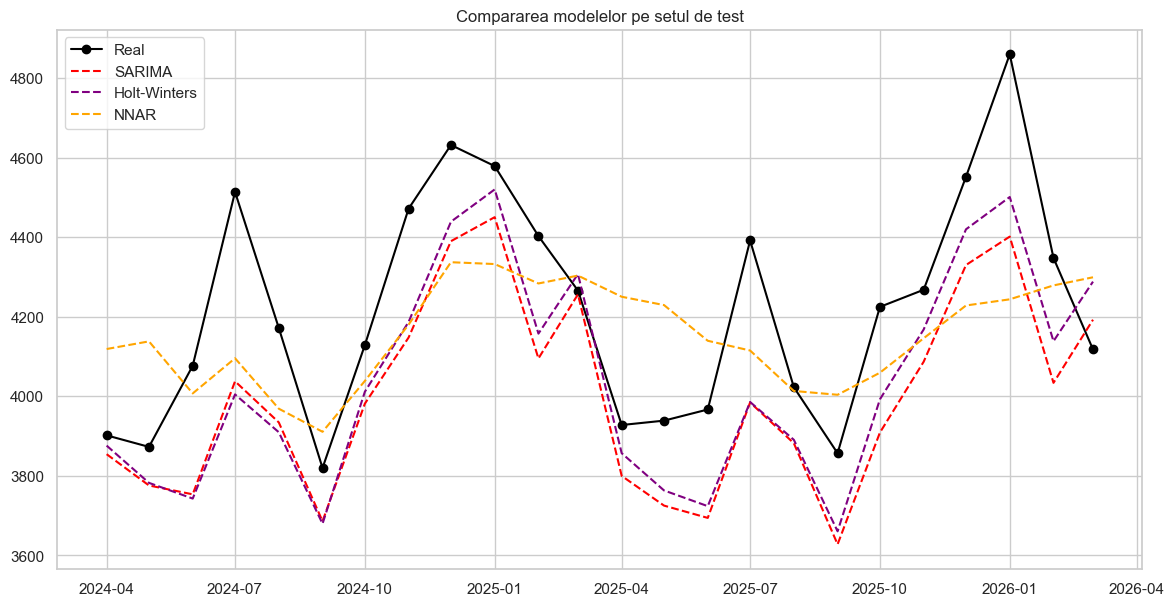

In [16]:
# 5. Tabel Comparativ Final
# (Aici introducem valorile colectate anterior pentru SARIMA și ETS)
final_comparison = pd.DataFrame({
    "SARIMA": [mae, mape, mase, rmse],
    "Holt-Winters (ETS)": [mae_hw, mape_hw, mase_hw, rmse_hw],
    "NNAR (MLP)": [mae_nnar, mape_nnar, mase_nnar, rmse_nnar]
}, index=["MAE", "MAPE (%)", "MASE", "RMSE"])

print("--- TABEL COMPARATIV FINAL: Acuratețe Modele ---")
print(final_comparison.T)

# 5. Vizualizare Comparativă (Zoom)
plt.figure(figsize=(14, 7))
plt.plot(test.index, test, label='Real', color='black', marker='o')
plt.plot(test.index, forecast_series, label='SARIMA', color='red', linestyle='--')
plt.plot(test.index, hw_forecast_series, label='Holt-Winters', color='purple', linestyle='--')
plt.plot(test.index, nnar_forecast_series, label='NNAR', color='orange', linestyle='--')

plt.title('Compararea modelelor pe setul de test')
plt.legend()
plt.grid(True)
plt.show()

Cel mai bun model conform metricilor MAE,MAPE,MASE si RMSE, unde luam cele mai mici valori, este netezirea exponentiala (H-W).

## Analiza multivariata

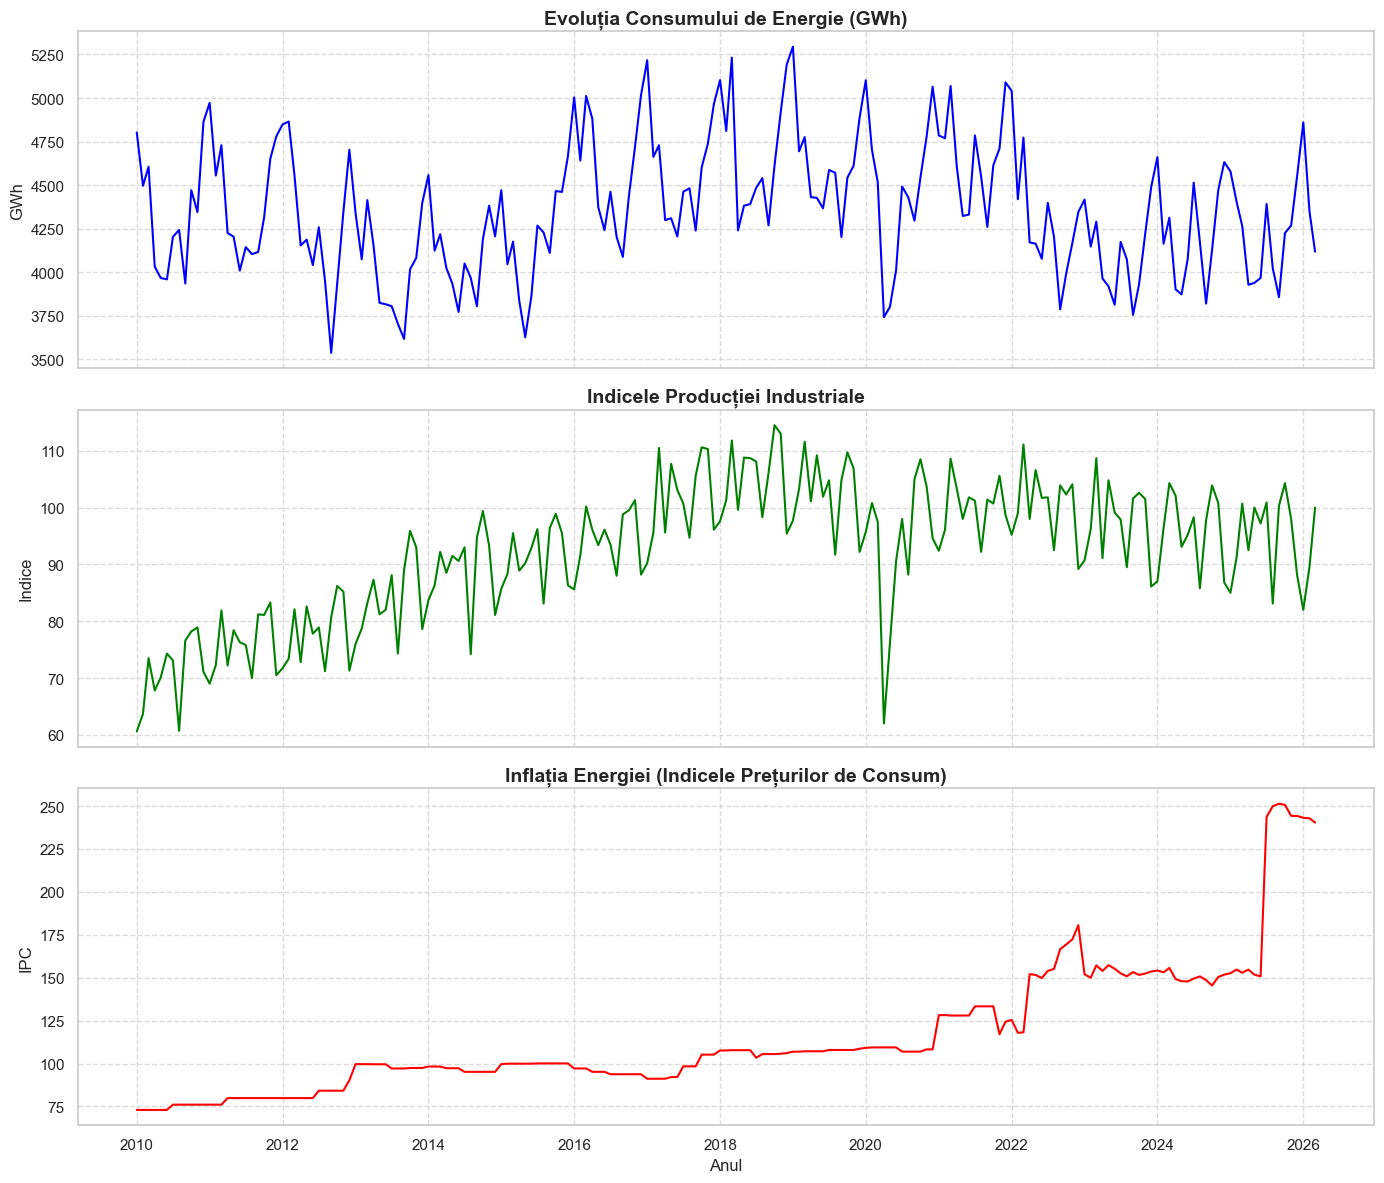

In [17]:
import matplotlib.pyplot as plt
import pandas as pd

# Presupunem că dataframe-ul tău se numește 'df'
# Asigură-te că data este setată ca index de tip datetime dacă nu este deja:
# df['date'] = pd.to_datetime(df['date'])
# df.set_index('date', inplace=True)

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# 1. Consum de Energie (Seria Ta Principală)
axes[0].plot(df.index, df['Consum_Energie_GWh'], color='blue', linewidth=1.5)
axes[0].set_title('Evoluția Consumului de Energie (GWh)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('GWh')
axes[0].grid(True, linestyle='--', alpha=0.7)

# 2. Producția Industrială
axes[1].plot(df.index, df['Productie_Industriala_Idx'], color='green', linewidth=1.5)
axes[1].set_title('Indicele Producției Industriale', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Indice')
axes[1].grid(True, linestyle='--', alpha=0.7)

# 3. Inflația Energiei (Prețul)
axes[2].plot(df.index, df['Inflatie_Energie_Ipc'], color='red', linewidth=1.5)
axes[2].set_title('Inflația Energiei (Indicele Prețurilor de Consum)', fontsize=14, fontweight='bold')
axes[2].set_ylabel('IPC')
axes[2].grid(True, linestyle='--', alpha=0.7)

# Setări generale
plt.xlabel('Anul', fontsize=12)
plt.tight_layout() # Așează graficele frumos, fără să se suprapună
plt.show()

Analiza celor trei indicatori macroeconomici pentru România reflectă impactul direct al crizelor recente asupra economiei naționale. Consumul de energie și producția industrială au o sezonalitate pronunțată și marchează o contracție severă în 2020 generată de restricțiile pandemice. După un deceniu de stabilitate, inflația pe segmentul energetic a explodat în 2021-2022 pe fondul crizei europene și a liberalizării pieței interne, înregistrând un nou șoc extrem în 2025. Această scumpire masivă a energiei a oprit avansul producției industriale post-pandemie și a generat o tendință generală de scădere a consumului național.

In [18]:
import numpy as np
import pandas as pd

# Creăm un dataframe nou care va prelua indexul de timp (data) din df-ul vechi
df_log = pd.DataFrame(index=df.index)

# Aplicăm logaritmul natural și creăm noile coloane
df_log['Consum_log'] = np.log(df['Consum_Energie_GWh'])
df_log['Productie_log'] = np.log(df['Productie_Industriala_Idx'])
df_log['Inflatie_log'] = np.log(df['Inflatie_Energie_Ipc'])

# Afișăm primele 5 rânduri ca să ne asigurăm că transformarea a reușit
df_log.head()

,Consum_log,Productie_log,Inflatie_log
date,,,
2010-01-01,8.476788,4.104295,4.290322
2010-02-01,8.410943,4.154185,4.290322
2010-03-01,8.435115,4.297285,4.290322
2010-04-01,8.302018,4.216562,4.290322
2010-05-01,8.285765,4.249923,4.290322


In [19]:
import pandas as pd
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.vector_ar.var_model import VAR

# 1. Cream un dataframe nou pentru seriile desezonalizate
df_clean = pd.DataFrame(index=df_log.index)

# Aplicam filtrul STL pentru a extrage sezonalitatea (doar pentru Consum si Productie)
for col in ['Consum_log', 'Productie_log']:
    # period=12 pentru date lunare; robust=True pentru a ignora valorile extreme la calculul trendului
    stl_model = STL(df_log[col], period=12, robust=True)
    rezultat_stl = stl_model.fit()
    
    # Seria curata este seria logaritmată din care scadem componenta sezoniera
    df_clean[col] = df_log[col] - rezultat_stl.seasonal

# Pentru Inflatie, o preluam asa cum e (ea nu are sezonalitate repetitiva)
df_clean['Inflatie_log'] = df_log['Inflatie_log']

Am scos componenta sezoniera din variabilele Consum si Indice productie industriala.

In [30]:
import warnings
from statsmodels.tsa.stattools import adfuller, kpss

warnings.filterwarnings("ignore")

def test_stationarity_log(series, title=''):
    print(f"=== {title} ===")
    
    # Test ADF
    adf_pvalue = adfuller(series.dropna(), autolag='AIC')[1]
    print(f"ADF p-value:  {adf_pvalue:.4f} -> {'Staționară (Respingem H0)' if adf_pvalue <= 0.05 else 'Non-staționară (Acceptăm H0)'}")

    # Test KPSS
    kpss_pvalue = kpss(series.dropna(), regression='c', nlags="auto")[1]
    print(f"KPSS p-value: {kpss_pvalue:.4f} -> {'Non-staționară (Respingem H0)' if kpss_pvalue <= 0.05 else 'Staționară (Acceptăm H0)'}")
    print("-" * 40)

# Rulăm pe coloanele logaritmate
for col in ['Consum_log', 'Productie_log', 'Inflatie_log']:
    test_stationarity_log(df_clean[col], title=col)

=== Consum_log ===
ADF p-value:  0.0838 -> Non-staționară (Acceptăm H0)
KPSS p-value: 0.1000 -> Staționară (Acceptăm H0)
----------------------------------------
=== Productie_log ===
ADF p-value:  0.1149 -> Non-staționară (Acceptăm H0)
KPSS p-value: 0.0100 -> Non-staționară (Respingem H0)
----------------------------------------
=== Inflatie_log ===
ADF p-value:  0.9558 -> Non-staționară (Acceptăm H0)
KPSS p-value: 0.0100 -> Non-staționară (Respingem H0)
----------------------------------------


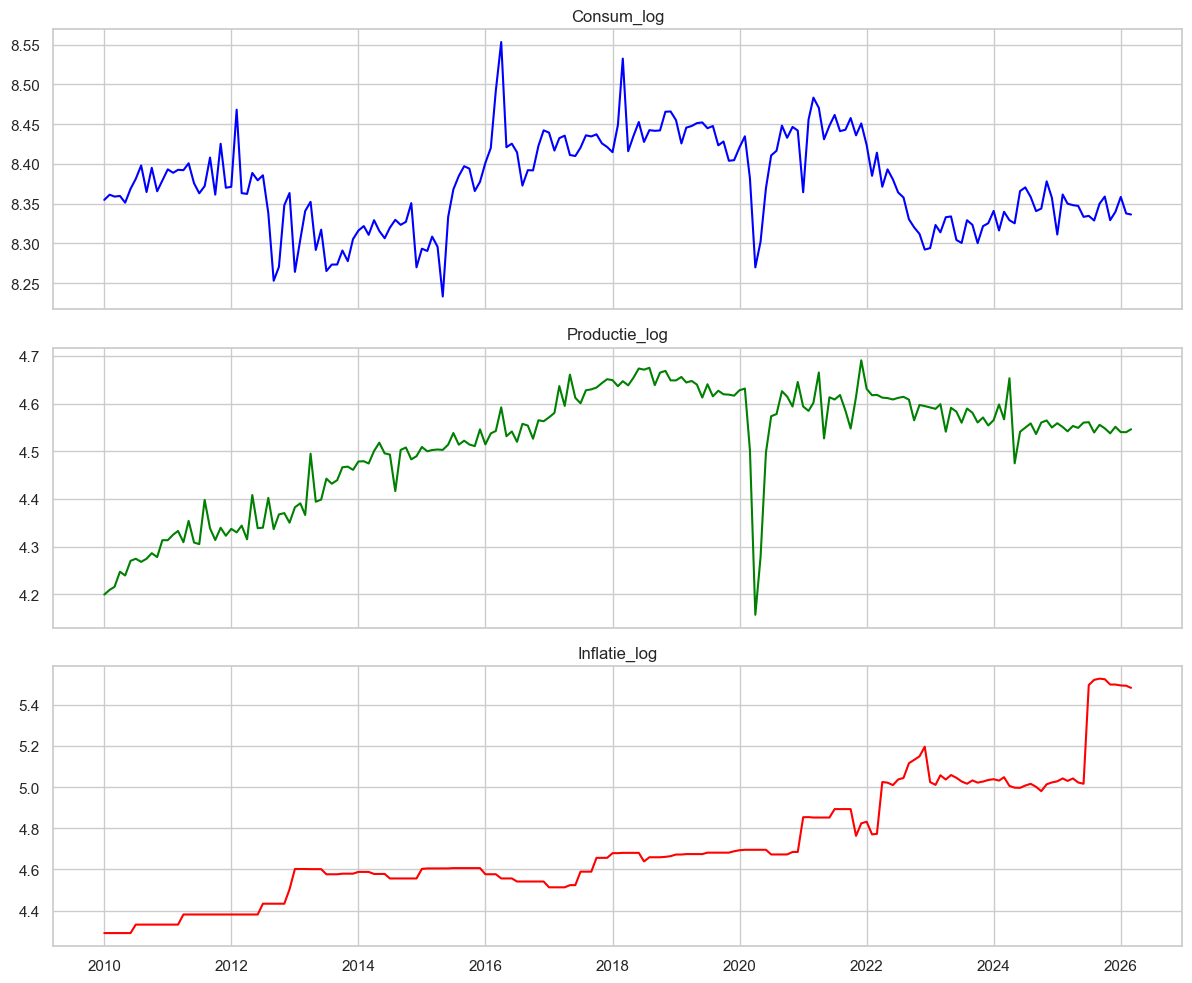

In [31]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axes[0].plot(df_clean['Consum_log'], color='blue')
axes[0].set_title('Consum_log')

axes[1].plot(df_clean['Productie_log'], color='green')
axes[1].set_title('Productie_log')

axes[2].plot(df_clean['Inflatie_log'], color='red')
axes[2].set_title('Inflatie_log')

plt.tight_layout()
plt.show()

In [33]:
# Creăm un dataframe nou cu prima diferență a seriilor logaritmate
# dropna() este obligatoriu pentru că diferențierea pierde primul rând
df_log_diff = df_clean.diff().dropna()

In [34]:
def test_stationarity_diff(series, title=''):
    print(f"=== {title} ===")
    
    # Test ADF (Vrem să respingem H0)
    adf_pvalue = adfuller(series, autolag='AIC')[1]
    print(f"ADF p-value:  {adf_pvalue:.4f} -> {'Staționară (Respingem H0)' if adf_pvalue <= 0.05 else 'Non-staționară (Acceptăm H0)'}")

    # Test KPSS (Vrem să acceptăm H0)
    kpss_pvalue = kpss(series, regression='c', nlags="auto")[1]
    print(f"KPSS p-value: {kpss_pvalue:.4f} -> {'Non-staționară (Respingem H0)' if kpss_pvalue <= 0.05 else 'Staționară (Acceptăm H0)'}")
    print("-" * 45)

# Rulăm testele pe seriile diferențiate
for col in ['Consum_log', 'Productie_log', 'Inflatie_log']:
    test_stationarity_diff(df_log_diff[col], title=col + " (Diferențiată)")

=== Consum_log (Diferențiată) ===
ADF p-value:  0.0000 -> Staționară (Respingem H0)
KPSS p-value: 0.1000 -> Staționară (Acceptăm H0)
---------------------------------------------
=== Productie_log (Diferențiată) ===
ADF p-value:  0.0000 -> Staționară (Respingem H0)
KPSS p-value: 0.0869 -> Staționară (Acceptăm H0)
---------------------------------------------
=== Inflatie_log (Diferențiată) ===
ADF p-value:  0.0000 -> Staționară (Respingem H0)
KPSS p-value: 0.1000 -> Staționară (Acceptăm H0)
---------------------------------------------


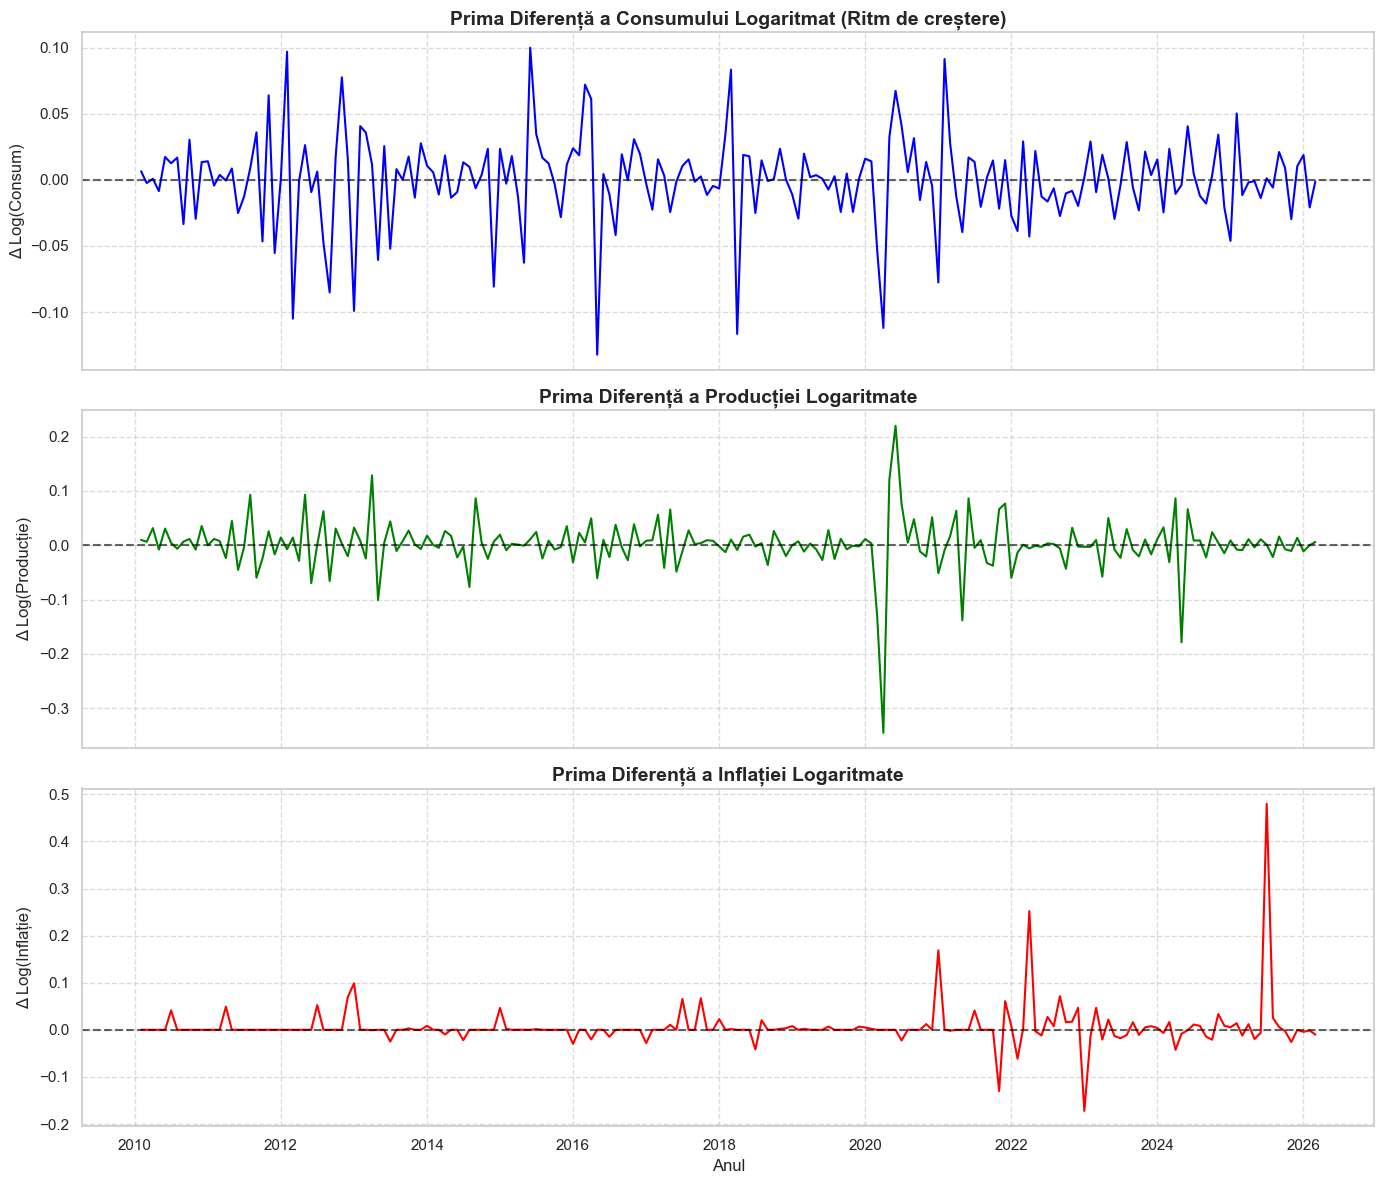

In [35]:
import matplotlib.pyplot as plt

# Creăm figura cu 3 grafice suprapuse
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# 1. Grafic Consum (Log Diferențiat)
axes[0].plot(df_log_diff.index, df_log_diff['Consum_log'], color='blue', linewidth=1.5)
axes[0].axhline(0, color='black', linestyle='--', alpha=0.6) # Linia de 0
axes[0].set_title('Prima Diferență a Consumului Logaritmat (Ritm de creștere)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Δ Log(Consum)')
axes[0].grid(True, linestyle='--', alpha=0.7)

# 2. Grafic Producție (Log Diferențiat)
axes[1].plot(df_log_diff.index, df_log_diff['Productie_log'], color='green', linewidth=1.5)
axes[1].axhline(0, color='black', linestyle='--', alpha=0.6) # Linia de 0
axes[1].set_title('Prima Diferență a Producției Logaritmate', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Δ Log(Producție)')
axes[1].grid(True, linestyle='--', alpha=0.7)

# 3. Grafic Inflație (Log Diferențiat)
axes[2].plot(df_log_diff.index, df_log_diff['Inflatie_log'], color='red', linewidth=1.5)
axes[2].axhline(0, color='black', linestyle='--', alpha=0.6) # Linia de 0
axes[2].set_title('Prima Diferență a Inflației Logaritmate', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Δ Log(Inflație)')
axes[2].grid(True, linestyle='--', alpha=0.7)

# Setări generale
plt.xlabel('Anul', fontsize=12)
plt.tight_layout()
plt.show()

In [37]:
import pandas as pd
import warnings
from statsmodels.tsa.api import VAR

warnings.filterwarnings("ignore")

# 1. Ne asigurăm că indexul este de tip datetime
df_log_diff.index = pd.to_datetime(df_log_diff.index)

# 2. Construim variabilele Dummy (exogene) pentru cele 3 șocuri
dummy_exog = pd.DataFrame(0, index=df_log_diff.index, columns=['Soc_Productie', 'Soc_Inflatie'])

# Șocul pe producție (Pandemia)
data_prod = pd.to_datetime('2020-04-01')
if data_prod in dummy_exog.index:
    dummy_exog.loc[data_prod, 'Soc_Productie'] = 1

# Șocurile pe inflație (Criza energiei)
data_inf1 = pd.to_datetime('2022-04-01')
data_inf2 = pd.to_datetime('2025-07-01')

if data_inf1 in dummy_exog.index:
    dummy_exog.loc[data_inf1, 'Soc_Inflatie'] = 1
if data_inf2 in dummy_exog.index:
    dummy_exog.loc[data_inf2, 'Soc_Inflatie'] = 1

# 3. Selectăm variabilele din dataframe-ul DIFERENȚIAT și curățat
df_model = df_log_diff[['Consum_log', 'Productie_log', 'Inflatie_log']].dropna()

# Ne asigurăm că dummy-urile se aliniază perfect cu rândurile din df_model
dummy_exog = dummy_exog.loc[df_model.index]

# 4. Inițializăm modelul VAR și bagam dummy-urile direct aici
model = VAR(df_model, exog=dummy_exog)

# 5. Căutăm lag-ul optim testând până la 12 luni (eliminăm exog de aici)
lag_results = model.select_order(maxlags=12, trend='n')

# Afișăm tabelul cu rezultate
print(lag_results.summary())

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -20.09     -19.98*   1.888e-09      -20.05
1       -20.21      -19.94   1.675e-09      -20.10
2      -20.31*      -19.89  1.513e-09*     -20.14*
3       -20.27      -19.69   1.568e-09      -20.04
4       -20.30      -19.56   1.530e-09      -20.00
5       -20.29      -19.40   1.538e-09      -19.93
6       -20.23      -19.17   1.642e-09      -19.80
7       -20.21      -19.00   1.672e-09      -19.72
8       -20.17      -18.80   1.745e-09      -19.62
9       -20.27      -18.73   1.594e-09      -19.64
10      -20.28      -18.59   1.577e-09      -19.59
11      -20.23      -18.39   1.655e-09      -19.48
12      -20.18      -18.17   1.761e-09      -19.36
--------------------------------------------------


AIC/FPE/HQIC sugereaza ca cel mai bun lag este 2.


In [40]:
import pandas as pd
from statsmodels.tsa.vector_ar.vecm import coint_johansen

# Rulăm testul Johansen pe datele în nivel (df_clean)
# k_ar_diff = 1 (pentru că lag-ul VAR ales a fost 2)
johansen_test = coint_johansen(df_clean, det_order=0, k_ar_diff=1)

# Extragem datele exclusiv pentru Tabelul Trace
trace_data = []
for i in range(len(johansen_test.lr1)):
    trace_data.append([
        f"r <= {i}",
        round(johansen_test.lr1[i], 4),    # Statistica Trace
        round(johansen_test.cvt[i, 0], 4), # Critic 90%
        round(johansen_test.cvt[i, 1], 4), # Critic 95%
        round(johansen_test.cvt[i, 2], 4)  # Critic 99%
    ])

df_trace = pd.DataFrame(trace_data, columns=["Ipoteza Nulă", "Statistica Trace", "Critic (90%)", "Critic (95%)", "Critic (99%)"])

# Afișăm tabelul
print("--- Statistica Trace (Johansen) ---")
print(df_trace.to_string(index=False))

--- Statistica Trace (Johansen) ---
Ipoteza Nulă  Statistica Trace  Critic (90%)  Critic (95%)  Critic (99%)
      r <= 0           27.6319       27.0669       29.7961       35.4628
      r <= 1           11.2033       13.4294       15.4943       19.9349
      r <= 2            0.0057        2.7055        3.8415        6.6349


Nu avem relatie de cointegrare la un nivel de incredere de 95%.

In [41]:
import pandas as pd
from statsmodels.tsa.api import VAR
import warnings

warnings.filterwarnings("ignore")

# 1. Definim clar datele de intrare: seriile DIFERENȚIATE
df_model = df_log_diff[['Consum_log', 'Productie_log', 'Inflatie_log']].dropna()

# 2. Ne asigurăm că dataframe-ul cu variabilele dummy are exact aceleași rânduri ca datele
dummy_exog_model = dummy_exog.loc[df_model.index]

# 3. Inițializăm modelul VAR introducând EXPLICIT variabilele endogene și exogenele
model = VAR(endog=df_model, exog=dummy_exog_model)

# 4. Estimăm modelul cu lag 2 și fără trend ('n' pentru că am diferențiat)
model_var = model.fit(2, trend='n')

# 5. Afișăm OUTPUT-ul complet al modelului
print("===================== REZUMAT MODEL VAR (LAG 2) =====================")
print(model_var.summary())

===================== REZUMAT MODEL VAR (LAG 2) =====================
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 06, Jun, 2026
Time:                     13:37:20
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -20.0292
Nobs:                     192.000    HQIC:                  -20.2714
Log likelihood:           1168.58    FPE:                1.33250e-09
AIC:                     -20.4364    Det(Omega_mle):     1.17892e-09
--------------------------------------------------------------------
Results for equation Consum_log
                      coefficient       std. error           t-stat            prob
-----------------------------------------------------------------------------------
Soc_Productie           -0.119757         0.032038           -3.738           0.000
Soc_Inflatie            -0.024232         0.022301       

Rezultatele estimarii modelului VAR cu doua decalaje confirma ca variabilele analizate nu se influenteaza reciproc in mod semnificativ pe termen scurt. Consumul de energie si productia industriala sunt determinate aproape exclusiv de propriile valori istorice din ultimele doua luni, avand coeficienti inalt semnificativi statistic. Dinamica inflatiei nu depinde de propriul istoric recent si nici de celelalte variabile, fiind dictata strict de socuri externe. Faptul ca toti coeficientii incrucisati au o probabilitate mult mai mare decat pragul de 0.05 demonstreaza matematic lipsa unei transmiteri a efectelor de la o variabila la alta, reconfirmand la nivel ecuational rigiditatea sistemului macroeconomic lunar.

In [45]:
# Rulăm testul de autocorelare a reziduurilor (Whiteness / Portmanteau Test)
# nlags=12 este o valoare standard și potrivită pentru un VAR cu lag 2 pe date lunare
rezultat_whiteness = model_var.test_whiteness(nlags=10)

print("--- Test Autocorelare Reziduuri (Whiteness) ---")
print(rezultat_whiteness.summary())

--- Test Autocorelare Reziduuri (Whiteness) ---
Portmanteau-test for residual autocorrelation. H_0: residual autocorrelation up to lag 10 is zero. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value df
----------------------------------------
         91.04          92.81   0.064 72
----------------------------------------


Conform testului Portmanteau, avand in vedere valoarea p value noi respingem H0, deci putem afirma ca nu avem autocorelare in reziduuri.

In [43]:
# 1. Testul de Normalitate a reziduurilor (Jarque-Bera)
rezultat_normalitate = model_var.test_normality()
print("--- Testul de Normalitate (Jarque-Bera) ---")
print(rezultat_normalitate.summary())

--- Testul de Normalitate (Jarque-Bera) ---
normality (skew and kurtosis) test. H_0: data generated by normally-distributed process. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value df
----------------------------------------
         1791.          12.59   0.000  6
----------------------------------------


In [47]:
import numpy as np
from statsmodels.stats.diagnostic import het_arch

# ==========================================
# 1. TESTUL DE STABILITATE VAR
# ==========================================
print("=== Verificare Stabilitate VAR ===")
is_stable = model_var.is_stable()

if is_stable:
    print("Concluzie: Modelul este STABIL (Toate rădăcinile sunt > 1).")
else:
    print("Concluzie: Modelul este INSTABIL (Avem rădăcini <= 1).")

print("\nValorile absolute ale rădăcinilor:")
for idx, root in enumerate(model_var.roots):
    print(f"Rădăcina {idx + 1}: {np.abs(root):.4f}")

print("\n" + "="*40 + "\n")

=== Verificare Stabilitate VAR ===
Concluzie: Modelul este STABIL (Toate rădăcinile sunt > 1).

Valorile absolute ale rădăcinilor:
Rădăcina 1: 21.8135
Rădăcina 2: 21.8135
Rădăcina 3: 1.9561
Rădăcina 4: 1.9561
Rădăcina 5: 1.9002
Rădăcina 6: 1.9002




In Python, radacina pe care o calculeaza programul este valoarea Z, adica radacina standard, si nu lambda. Din acest motiv, valoarea Z trebuie sa fie strict mai mare decat 1 pentru ca modelul sa fie stabil. Valorile depasesc 1, deci modelul este perfect corect si stabil.

In [48]:
# Lista variabilelor din modelul tau
variabile = model_var.names

print("=== TESTUL DE CAUZALITATE GRANGER ===")
print("Regula: Daca p-value < 0.05, atunci X cauzeaza Granger Y.\n")

for cauzata in variabile:
    for cauzatoare in variabile:
        if cauzata != cauzatoare:
            # Rulam testul pentru fiecare pereche
            rezultat = model_var.test_causality(caused=cauzata, causing=cauzatoare, kind='f')
            p_value = rezultat.pvalue
            
            # Tragem concluzia pe baza lui p-value
            if p_value < 0.05:
                concluzie = "DA (Exista cauzalitate)"
            else:
                concluzie = "NU (Nu exista cauzalitate)"
                
            print(f"Testam: {cauzatoare} influenteaza {cauzata}?")
            print(f"p-value: {round(p_value, 4)} -> {concluzie}")
            print("-" * 45)

=== TESTUL DE CAUZALITATE GRANGER ===
Regula: Daca p-value < 0.05, atunci X cauzeaza Granger Y.

Testam: Productie_log influenteaza Consum_log?
p-value: 0.7213 -> NU (Nu exista cauzalitate)
---------------------------------------------
Testam: Inflatie_log influenteaza Consum_log?
p-value: 0.9415 -> NU (Nu exista cauzalitate)
---------------------------------------------
Testam: Consum_log influenteaza Productie_log?
p-value: 0.2297 -> NU (Nu exista cauzalitate)
---------------------------------------------
Testam: Inflatie_log influenteaza Productie_log?
p-value: 0.8596 -> NU (Nu exista cauzalitate)
---------------------------------------------
Testam: Consum_log influenteaza Inflatie_log?
p-value: 0.3687 -> NU (Nu exista cauzalitate)
---------------------------------------------
Testam: Productie_log influenteaza Inflatie_log?
p-value: 0.5401 -> NU (Nu exista cauzalitate)
---------------------------------------------


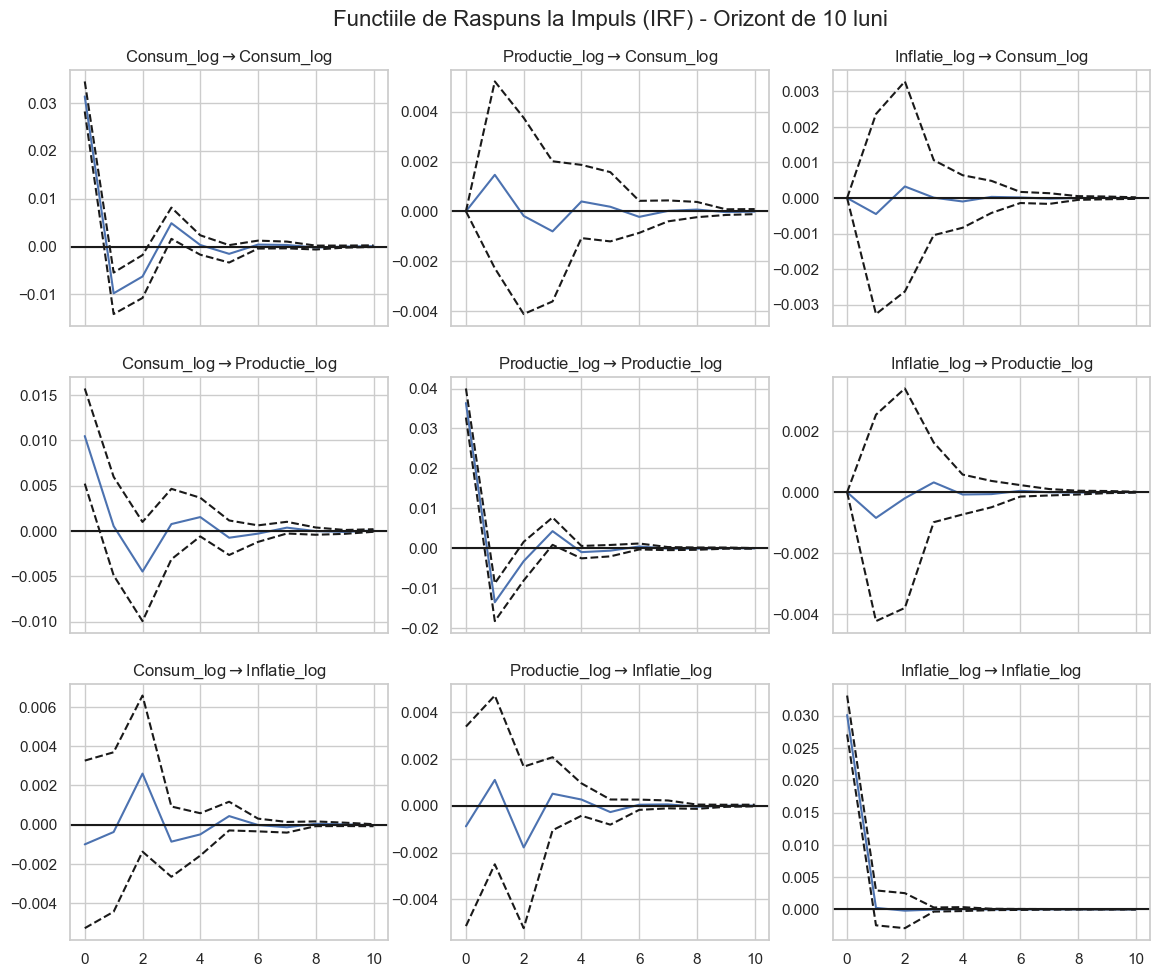

In [49]:
import matplotlib.pyplot as plt

# Generam functiile IRF pe un orizont de 10 luni
# orth=True asigura folosirea socurilor ortogonalizate Cholesky (este setarea standard)
irf = model_var.irf(10)

# Generam graficul mare cu toate cele 9 subgrafice
fig = irf.plot(orth=True, figsize=(12, 10))
fig.suptitle('Functiile de Raspuns la Impuls (IRF) - Orizont de 10 luni', fontsize=16)
plt.subplots_adjust(top=0.92) # Ajustam putin spatiul pentru titlu
plt.show()

=== DESCOMPUNEREA VARIANTEI (FEVD) ===
FEVD for Consum_log
     Consum_log  Productie_log  Inflatie_log
0      1.000000       0.000000      0.000000
1      0.997825       0.001988      0.000187
2      0.997777       0.001948      0.000275
3      0.997258       0.002473      0.000269
4      0.997114       0.002609      0.000277
5      0.997090       0.002633      0.000277
6      0.997047       0.002675      0.000278
7      0.997047       0.002675      0.000278
8      0.997043       0.002680      0.000278
9      0.997042       0.002681      0.000278

FEVD for Productie_log
     Consum_log  Productie_log  Inflatie_log
0      0.076538       0.923462      0.000000
1      0.068036       0.931523      0.000441
2      0.078990       0.920553      0.000457
3      0.078425       0.921060      0.000514
4      0.079671       0.919812      0.000516
5      0.079967       0.919514      0.000518
6      0.080006       0.919474      0.000520
7      0.080077       0.919403      0.000520
8      0.080077  

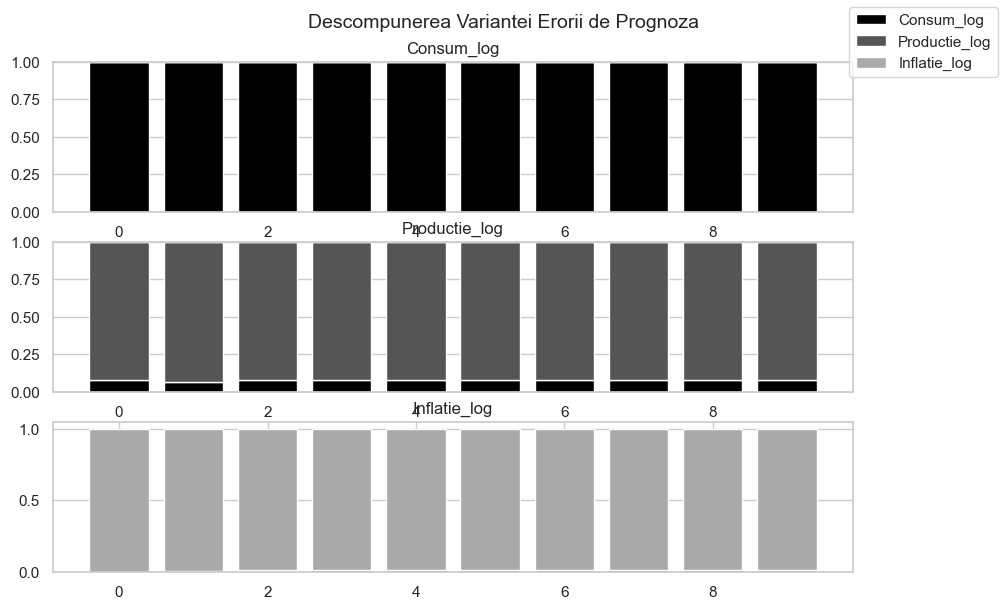

In [50]:
import matplotlib.pyplot as plt

# ==========================================
# DESCOMPUNEREA VARIANTEI (FEVD) pe 10 luni
# ==========================================
fevd = model_var.fevd(10)

# Afisam tabelul in consola
print("=== DESCOMPUNEREA VARIANTEI (FEVD) ===")
print(fevd.summary())

# Generam si graficul colorat
fig = fevd.plot(figsize=(10, 6))
plt.suptitle('Descompunerea Variantei Erorii de Prognoza', fontsize=14)
plt.subplots_adjust(top=0.9)
plt.show()

Analiza descompunerii variantei erorii de prognoza arata o exogenitate foarte ridicata pentru toate cele trei serii de timp pe orizontul de zece luni. Varianta consumului de energie este dictata in proportie de 99.7 la suta exclusiv de propriile sale socuri istorice, iar dinamica inflatiei este autodeterminata in proportie de 98.4 la suta. Singura influenta incrucisata minora se observa in cazul productiei industriale unde consumul de energie reuseste sa explice aproximativ 8 la suta din varianta, sugerand o dependenta operationala imediata. In concluzie sistemul macroeconomic se dovedeste a fi extrem de rigid pe termen scurt, fiecare indicator evoluand independent pe propria traiectorie fara efecte de contagiune din partea celorlalte variabile.

# Deep learning

In [57]:
import random

# Fixăm seed-ul pentru ca PyTorch să nu mai genereze rezultate random la fiecare rulare
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)


--- Incepem antrenarea modelului LSTM cu Early Stopping ---
Epoca [10/500], Train Loss: 0.046322, Val Loss: 0.035585
Epoca [20/500], Train Loss: 0.034532, Val Loss: 0.030069
Epoca [30/500], Train Loss: 0.035185, Val Loss: 0.027623
Epoca [40/500], Train Loss: 0.030574, Val Loss: 0.028470
Epoca [50/500], Train Loss: 0.022425, Val Loss: 0.026664
Epoca [60/500], Train Loss: 0.022276, Val Loss: 0.025839
Epoca [70/500], Train Loss: 0.022030, Val Loss: 0.028066
Epoca [77/500], Train Loss: 0.019623, Val Loss: 0.026745

[!] Antrenament oprit timpuriu la epoca 77.
[!] Modelul se intoarce la cea mai buna epoca (Val Loss: 0.025728).

=== PERFORMANTA FINALA LSTM MULTIVARIAT (PyTorch) ===
MAE:  0.0504
RMSE: 0.0647
MAPE: 0.6027%
MASE: 0.9620


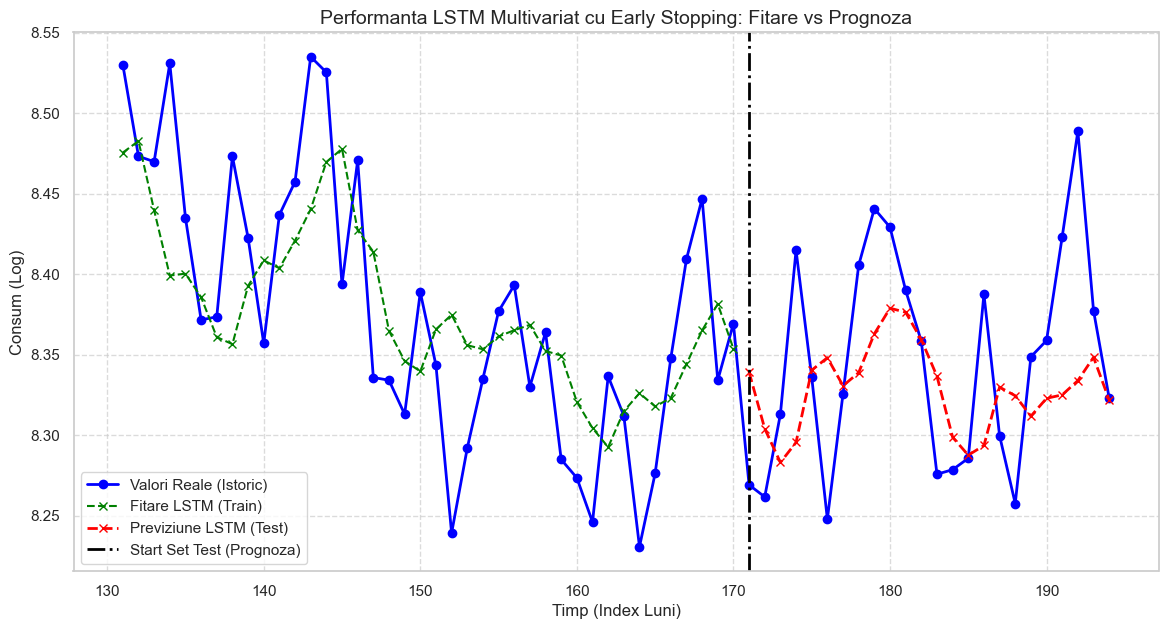

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import copy

# ==========================================
# 1. PREGATIREA DATELOR
# ==========================================
date_model = df_log[['Consum_log', 'Productie_log', 'Inflatie_log']].values

scaler = MinMaxScaler(feature_range=(0, 1))
date_scalate = scaler.fit_transform(date_model)

def creeaza_secvente(dataset, look_back=12):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), :]) 
        Y.append(dataset[i + look_back, 0])     
    return np.array(X), np.array(Y)

look_back = 12
X, Y = creeaza_secvente(date_scalate, look_back)

# ==========================================
# 2. DELIMITARE TRAINING SI TEST SET
# ==========================================
dimensiune_test = 24
split_idx = len(X) - dimensiune_test

X_train, X_test = X[:split_idx], X[split_idx:]
Y_train, Y_test = Y[:split_idx], Y[split_idx:]

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
Y_train_tensor = torch.tensor(Y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
Y_test_tensor = torch.tensor(Y_test, dtype=torch.float32).view(-1, 1)

train_data = TensorDataset(X_train_tensor, Y_train_tensor)
train_loader = DataLoader(train_data, batch_size=16, shuffle=False)

# ==========================================
# 3. CONSTRUIREA ARHITECTURII LSTM
# ==========================================
class LSTMMultivariat(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(LSTMMultivariat, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.dropout = nn.Dropout(0.2)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.dropout(out)
        out = self.fc(out[:, -1, :]) 
        return out

model_lstm = LSTMMultivariat(input_size=3, hidden_size=50, num_layers=1, output_size=1)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_lstm.parameters(), lr=0.001)

# ==========================================
# 4. ANTRENAREA MODELULUI CU EARLY STOPPING
# ==========================================
print("\n--- Incepem antrenarea modelului LSTM cu Early Stopping ---")

epochs = 500
patience = 15
patience_counter = 0
best_val_loss = float('inf')
best_model_weights = None

for epoch in range(epochs):
    model_lstm.train()
    train_loss = 0.0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model_lstm(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * batch_x.size(0)
    train_loss /= len(train_loader.dataset)
    
    model_lstm.eval()
    with torch.no_grad():
        val_outputs = model_lstm(X_test_tensor)
        val_loss = criterion(val_outputs, Y_test_tensor).item()
        
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_weights = copy.deepcopy(model_lstm.state_dict())
    else:
        patience_counter += 1
        
    if (epoch + 1) % 10 == 0 or patience_counter >= patience:
        print(f'Epoca [{epoch+1}/{epochs}], Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}')
        
    if patience_counter >= patience:
        print(f'\n[!] Antrenament oprit timpuriu la epoca {epoch+1}.')
        print(f'[!] Modelul se intoarce la cea mai buna epoca (Val Loss: {best_val_loss:.6f}).')
        break

model_lstm.load_state_dict(best_model_weights)

# ==========================================
# 5. PREVIZIUNE (Pe Test si pe o portiune de Train)
# ==========================================
luni_train_vizibile = 40 

model_lstm.eval() 
with torch.no_grad(): 
    predictii_test_scalate = model_lstm(X_test_tensor).numpy()
    predictii_train_scalate = model_lstm(X_train_tensor[-luni_train_vizibile:]).numpy()

dummy_pred_test = np.zeros((len(predictii_test_scalate), 3))
dummy_pred_test[:, 0] = predictii_test_scalate[:, 0]
predictii_reale_test = scaler.inverse_transform(dummy_pred_test)[:, 0]

dummy_pred_train = np.zeros((len(predictii_train_scalate), 3))
dummy_pred_train[:, 0] = predictii_train_scalate[:, 0]
predictii_reale_train = scaler.inverse_transform(dummy_pred_train)[:, 0]

dummy_test = np.zeros((len(Y_test), 3))
dummy_test[:, 0] = Y_test.reshape(-1)
valori_reale_test = scaler.inverse_transform(dummy_test)[:, 0]

# ==========================================
# 6. EVALUAREA PERFORMANTEI (Calculata STRICT pe Test Set)
# ==========================================
mae_lstm = mean_absolute_error(valori_reale_test, predictii_reale_test)
rmse_lstm = np.sqrt(mean_squared_error(valori_reale_test, predictii_reale_test))
mape_lstm = np.mean(np.abs((valori_reale_test - predictii_reale_test) / valori_reale_test)) * 100

# --- CALCUL MASE (Mean Absolute Scaled Error) ---
valori_reale_train = date_model[:-dimensiune_test, 0]
m = 12
mae_naiv_sezonier = np.mean(np.abs(valori_reale_train[m:] - valori_reale_train[:-m]))
mase_lstm = mae_lstm / mae_naiv_sezonier

print("\n=== PERFORMANTA FINALA LSTM MULTIVARIAT (PyTorch) ===")
print(f"MAE:  {mae_lstm:.4f}")
print(f"RMSE: {rmse_lstm:.4f}")
print(f"MAPE: {mape_lstm:.4f}%")
print(f"MASE: {mase_lstm:.4f}")

# ==========================================
# 7. REPREZENTARE GRAFICA EXTINSA (Train + Test)
# ==========================================
plt.figure(figsize=(14, 7))

total_luni = dimensiune_test + luni_train_vizibile
index_timp_total = range(len(df_log) - total_luni, len(df_log))
index_timp_train = range(len(df_log) - total_luni, len(df_log) - dimensiune_test)
index_timp_test = range(len(df_log) - dimensiune_test, len(df_log))

valori_reale_totale = date_model[-total_luni:, 0]

plt.plot(index_timp_total, valori_reale_totale, label='Valori Reale (Istoric)', color='blue', marker='o', linewidth=2)
plt.plot(index_timp_train, predictii_reale_train, label='Fitare LSTM (Train)', color='green', linestyle='dashed', marker='x')
plt.plot(index_timp_test, predictii_reale_test, label='Previziune LSTM (Test)', color='red', linestyle='dashed', marker='x', linewidth=2)

plt.axvline(x=index_timp_test[0], color='black', linestyle='-.', linewidth=2, label='Start Set Test (Prognoza)')

plt.title('Performanta LSTM Multivariat cu Early Stopping: Fitare vs Prognoza', fontsize=14)
plt.xlabel('Timp (Index Luni)', fontsize=12)
plt.ylabel('Consum (Log)', fontsize=12)
plt.legend(loc='lower left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Oprirea timpurie la epoca 77 a prevenit cu succes fenomenul de overfitting. Modelul capteaza corect tendinta principala a consumului si netezeste deliberat extremele pentru a pastra o capacitate ridicata de generalizare pe date necunoscute. Aceasta stabilitate este confirmata pe setul de testare de o eroare medie absoluta de 0.0504 si un MAPE sub 1 procent. In concluzie reteaua LSTM invata eficient interdependentele macroeconomice reale si ofera o predictie robusta fara sa memoreze zgomotul haotic al pietei.